In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import os

os.chdir(Path.cwd().parent)
print("new cwd:", Path.cwd())

new cwd: /home/oliver-hertach/Documents/Master/CO4/ClimbingVault


## Shared constants

In [2]:
colors = {
    "red": [255, 0, 0],
    "blue": [0, 0, 255],
    "green": [0, 255, 0],
    "yellow": [255, 255, 0],
    "orange": [255, 165, 0],
    "purple": [128, 0, 128],
    "pink" : [255, 105, 180],
    "black": [0, 0, 0],
    "downclimb": [128, 128, 128],
}

## Shared functions

In [ ]:
def load_sample(img_id):
    img = cv.imread(f"data/images/{img_id}.jpg")

    mask_dir = f"data/masks/{img_id}"
    
    masks = {}
    
    for file in os.listdir(mask_dir):
        if file.endswith(".png"):
            color = file.replace(".png", "")
            masks[color] = cv.imread(os.path.join(mask_dir, file), 0)

    return img, masks

# Dice score
def dice_score(gt, pred):
    intersection = np.sum(gt * pred)
    return (2 * intersection) / (np.sum(gt) + np.sum(pred))

## Combined plotting of RGB vs HSV vs YUV

NameError: name 'rgb_dice' is not defined

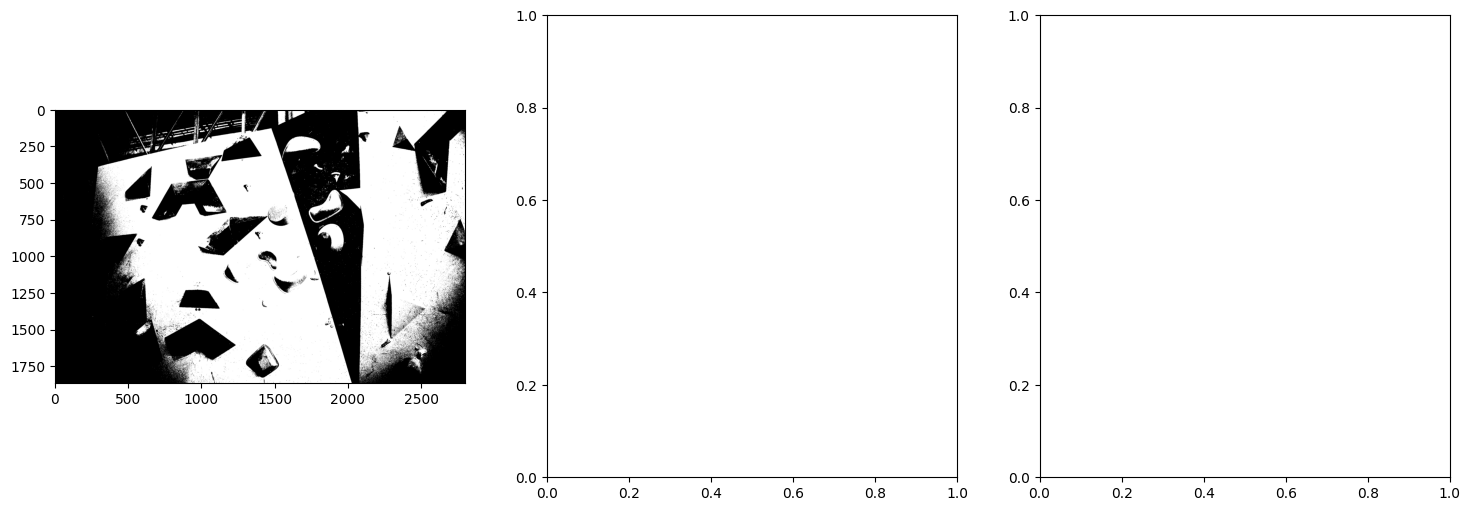

In [ ]:
img_id = "008"

img, masks = load_sample(img_id)

# Convert color spaces
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
yuv = cv.cvtColor(img, cv.COLOR_BGR2YUV)

# Ground truth
gt = (masks["green"] > 0).astype(np.uint8)

# -----------------------------
# RGB segmentation
# -----------------------------
rgb_lower = np.array([0, 80, 0])
rgb_upper = np.array([180, 255, 180])

rgb_mask = cv.inRange(img_rgb, rgb_lower, rgb_upper)
rgb_pred = (rgb_mask > 0).astype(np.uint8)

# -----------------------------
# HSV segmentation
# -----------------------------
hsv_lower = np.array([35, 50, 50])
hsv_upper = np.array([85, 255, 255])

hsv_mask = cv.inRange(hsv, hsv_lower, hsv_upper)
hsv_pred = (hsv_mask > 0).astype(np.uint8)

# -----------------------------
# YUV segmentation
# -----------------------------
yuv_lower = np.array([0, 40, 0])
yuv_upper = np.array([255, 120, 140])

yuv_mask = cv.inRange(yuv, yuv_lower, yuv_upper)
yuv_pred = (yuv_mask > 0).astype(np.uint8)

# -----------------------------
# Dice scores
# -----------------------------
rgb_dice = dice_score(gt, rgb_pred)
hsv_dice = dice_score(gt, hsv_pred)
yuv_dice = dice_score(gt, yuv_pred)

print("RGB Dice:", rgb_dice)
print("HSV Dice:", hsv_dice)
print("YUV Dice:", yuv_dice)

# -----------------------------
# MASK VISUALIZATION
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(rgb_mask, cmap="gray")
axes[0].set_title(f"RGB Mask\nDice: {rgb_dice:.3f}")
axes[0].axis("off")

axes[1].imshow(hsv_mask, cmap="gray")
axes[1].set_title(f"HSV Mask\nDice: {hsv_dice:.3f}")
axes[1].axis("off")

axes[2].imshow(yuv_mask, cmap="gray")
axes[2].set_title(f"YUV Mask\nDice: {yuv_dice:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# OVERLAY VISUALIZATION
# -----------------------------
rgb_overlay = img_rgb.copy()
rgb_overlay[rgb_pred == 1] = [0,255,0]

hsv_overlay = img_rgb.copy()
hsv_overlay[hsv_pred == 1] = [0,255,0]

yuv_overlay = img_rgb.copy()
yuv_overlay[yuv_pred == 1] = [0,255,0]

fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(rgb_overlay)
axes[0].set_title("RGB Overlay")
axes[0].axis("off")

axes[1].imshow(hsv_overlay)
axes[1].set_title("HSV Overlay")
axes[1].axis("off")

axes[2].imshow(yuv_overlay)
axes[2].set_title("YUV Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()